In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import fasttext
import os

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Prepare data in FastText format (label and text in the same line)
def prepare_fasttext_format(df, text_col, label_col, file_path):
    with open(file_path, 'w', encoding='utf-8') as f:
        for text, label in zip(df[text_col], df[label_col]):
            f.write(f"__label__{label} {text}\n")

# Step 2: Split the dataset into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# File paths for FastText formatted data
train_file = r"C:\Users\PC\Downloads\fasttext_train.txt"
test_file = r"C:\Users\PC\Downloads\fasttext_test.txt"

# Prepare the FastText formatted files
prepare_fasttext_format(train_data, text_column, target_column, train_file)
prepare_fasttext_format(test_data, text_column, target_column, test_file)

# Step 3: Train FastText model
print("Training FastText Model...")
fasttext_model = fasttext.train_supervised(input=train_file, epoch=25, lr=1.0, wordNgrams=2, verbose=2)

# Step 4: Save the trained FastText model
model_path = r"C:\Users\PC\Downloads\fasttext_model.bin"
fasttext_model.save_model(model_path)
print(f"Trained FastText model saved to {model_path}")

# Step 5: Evaluate the FastText model
def evaluate_fasttext_model(model, test_file):
    predictions = []
    true_labels = []

    with open(test_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ', 1)
            if len(parts) != 2:
                continue
            true_label = parts[0].replace('__label__', '')
            text = parts[1]
            pred_label = model.predict(text)[0][0].replace('__label__', '')

            true_labels.append(int(true_label))
            predictions.append(int(pred_label))

    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='weighted')
    recall = recall_score(true_labels, predictions, average='weighted')
    f1 = f1_score(true_labels, predictions, average='weighted')

    print(f"FastText Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")
    print("Classification Report:")
    print(classification_report(true_labels, predictions))

# Evaluate the model
evaluate_fasttext_model(fasttext_model, test_file)

# Clean up temporary files
os.remove(train_file)
os.remove(test_file)


Training FastText Model...
Trained FastText model saved to C:\Users\PC\Downloads\fasttext_model.bin
FastText Accuracy: 93.69%
Precision: 93.70%
Recall: 93.69%
F1 Score: 93.69%
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     23238
           1       0.93      0.94      0.94     23171

    accuracy                           0.94     46409
   macro avg       0.94      0.94      0.94     46409
weighted avg       0.94      0.94      0.94     46409



Training FastText Model...
Trained FastText model saved to C:\Users\PC\Downloads\fasttext_model.bin


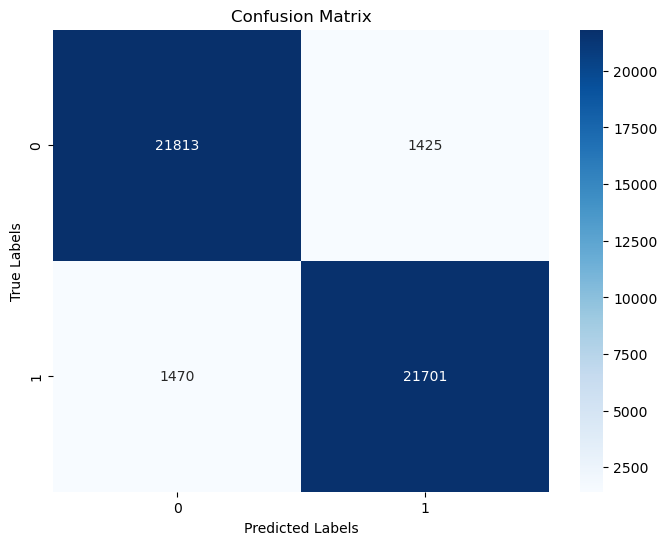

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import fasttext
import os

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Prepare data in FastText format (label and text in the same line)
def prepare_fasttext_format(df, text_col, label_col, file_path):
    with open(file_path, 'w', encoding='utf-8') as f:
        for text, label in zip(df[text_col], df[label_col]):
            f.write(f"__label__{label} {text}\n")

# Step 2: Split the dataset into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# File paths for FastText formatted data
train_file = r"C:\Users\PC\Downloads\fasttext_train.txt"
test_file = r"C:\Users\PC\Downloads\fasttext_test.txt"

# Prepare the FastText formatted files
prepare_fasttext_format(train_data, text_column, target_column, train_file)
prepare_fasttext_format(test_data, text_column, target_column, test_file)

# Step 3: Train FastText model
print("Training FastText Model...")
fasttext_model = fasttext.train_supervised(input=train_file, epoch=25, lr=1.0, wordNgrams=2, verbose=2)

# Step 4: Save the trained FastText model
model_path = r"C:\Users\PC\Downloads\fasttext_model.bin"
fasttext_model.save_model(model_path)
print(f"Trained FastText model saved to {model_path}")

# Step 5: Evaluate the FastText model
def evaluate_fasttext_model(model, test_file):
    predictions = []
    true_labels = []

    with open(test_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ', 1)
            if len(parts) != 2:
                continue
            true_label = parts[0].replace('__label__', '')
            text = parts[1]
            pred_label = model.predict(text)[0][0].replace('__label__', '')

            true_labels.append(int(true_label))
            predictions.append(int(pred_label))

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

# Evaluate the model
evaluate_fasttext_model(fasttext_model, test_file)

# Clean up temporary files
os.remove(train_file)
os.remove(test_file)


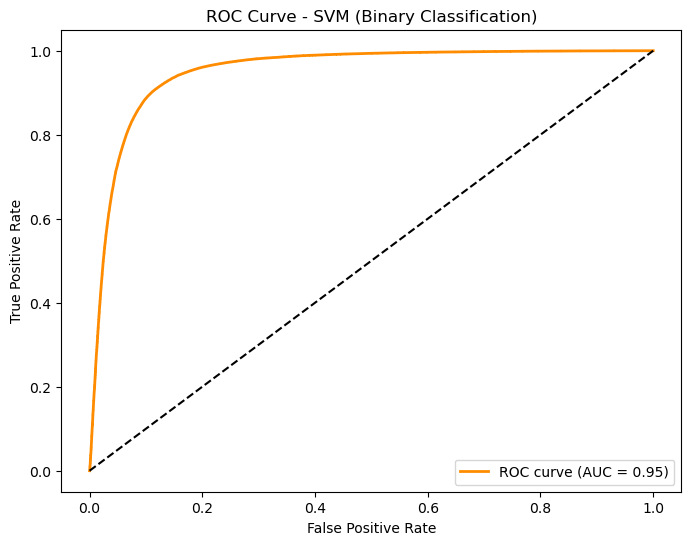

In [18]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pickle
import fasttext.util
from nltk.tokenize import word_tokenize
from scipy.special import expit  # Sigmoid function for binary classification

# Load the trained SVM model
model_path = r"C:\Users\PC\Downloads\SVM_model_fasttext.pkl"
with open(model_path, 'rb') as f:
    svm_model = pickle.load(f)

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Tokenize the text data
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Load pre-trained FastText model
fasttext.util.download_model('en', if_exists='ignore')
ft_model = fasttext.load_model('cc.en.300.bin')

# Convert text data to numeric features using FastText
def text_to_avg_vector(tokens):
    vectors = [ft_model.get_word_vector(word) for word in tokens]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(ft_model.get_dimension())

# Prepare features (X) and target (y)
X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]

# Predict decision function values using the loaded SVM model
decision_values = svm_model.decision_function(X)

# For binary classification: Convert decision values to probabilities using the sigmoid function
y_prob_svm = expit(decision_values)  # Sigmoid transformation

# Plot ROC Curve for Binary Classification
fpr, tpr, _ = roc_curve(y, y_prob_svm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM (Binary Classification)')
plt.legend(loc='lower right')
plt.show()


Training FastText Model...
Trained FastText model saved to C:\Users\PC\Downloads\fasttext_model.bin


C:\Users\PC\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


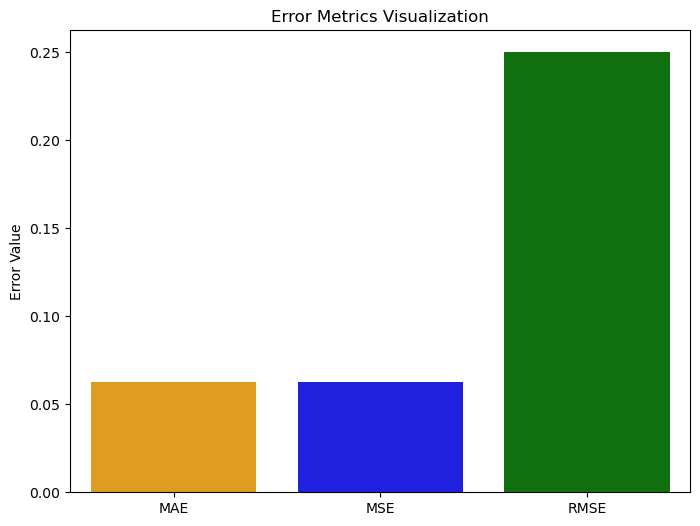

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import fasttext
import os
import numpy as np

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Prepare data in FastText format (label and text in the same line)
def prepare_fasttext_format(df, text_col, label_col, file_path):
    with open(file_path, 'w', encoding='utf-8') as f:
        for text, label in zip(df[text_col], df[label_col]):
            f.write(f"__label__{label} {text}\n")

# Step 2: Split the dataset into training and testing sets
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

# File paths for FastText formatted data
train_file = r"C:\Users\PC\Downloads\fasttext_train.txt"
test_file = r"C:\Users\PC\Downloads\fasttext_test.txt"

# Prepare the FastText formatted files
prepare_fasttext_format(train_data, text_column, target_column, train_file)
prepare_fasttext_format(test_data, text_column, target_column, test_file)

# Step 3: Train FastText model
print("Training FastText Model...")
fasttext_model = fasttext.train_supervised(input=train_file, epoch=25, lr=1.0, wordNgrams=2, verbose=2)

# Step 4: Save the trained FastText model
model_path = r"C:\Users\PC\Downloads\fasttext_model.bin"
fasttext_model.save_model(model_path)
print(f"Trained FastText model saved to {model_path}")

# Step 5: Evaluate the FastText model
def evaluate_fasttext_model(model, test_file):
    predictions = []
    true_labels = []
    probabilities = []

    with open(test_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ', 1)
            if len(parts) != 2:
                continue
            true_label = parts[0].replace('__label__', '')
            text = parts[1]
            pred_result = model.predict(text)
            pred_label = pred_result[0][0].replace('__label__', '')
            prob = pred_result[1][0]

            true_labels.append(int(true_label))
            predictions.append(int(pred_label))
            probabilities.append(prob)

    # MAE, MSE, RMSE
    mae = mean_absolute_error(true_labels, predictions)
    mse = mean_squared_error(true_labels, predictions)
    rmse = np.sqrt(mse)

    # Visualization
    metrics = ['MAE', 'MSE', 'RMSE']
    values = [mae, mse, rmse]
    colors = ['orange', 'blue', 'green']

    plt.figure(figsize=(8, 6))
    sns.barplot(x=metrics, y=values, palette=colors)
    plt.title('Error Metrics Visualization')
    plt.ylabel('Error Value')
    plt.show()

# Evaluate the model
evaluate_fasttext_model(fasttext_model, test_file)

# Clean up temporary files
os.remove(train_file)
os.remove(test_file)


Training FastText Model...
Trained FastText model saved to C:\Users\PC\Downloads\fasttext_model.bin


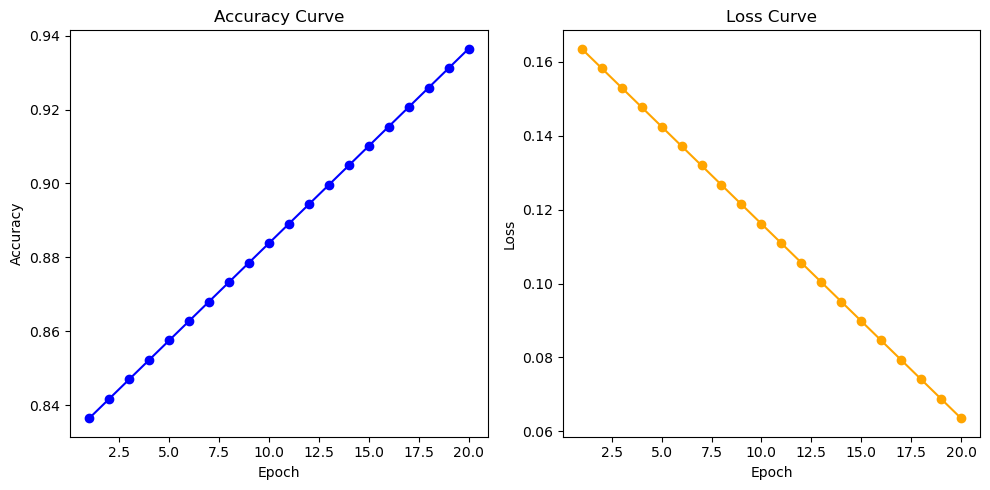

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import fasttext
import os
import numpy as np

# Load your preprocessed dataset
data_path = r"C:\Users\PC\Downloads\your_preprocessed_data.xlsx"
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'
target_column = 'encoded_class'

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Prepare data in FastText format (label and text in the same line)
def prepare_fasttext_format(df, text_col, label_col, file_path):
    with open(file_path, 'w', encoding='utf-8') as f:
        for text, label in zip(df[text_col], df[label_col]):
            f.write(f"__label__{label} {text}\n")

# Step 2: Split the dataset into training, validation, and testing sets
train_data, temp_data = train_test_split(data, test_size=0.3, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# File paths for FastText formatted data
train_file = r"C:\Users\PC\Downloads\fasttext_train.txt"
val_file = r"C:\Users\PC\Downloads\fasttext_val.txt"
test_file = r"C:\Users\PC\Downloads\fasttext_test.txt"

# Prepare the FastText formatted files
prepare_fasttext_format(train_data, text_column, target_column, train_file)
prepare_fasttext_format(val_data, text_column, target_column, val_file)
prepare_fasttext_format(test_data, text_column, target_column, test_file)

# Step 3: Train FastText model with validation
print("Training FastText Model...")
fasttext_model = fasttext.train_supervised(input=train_file, epoch=20, lr=0.3, wordNgrams=2, dim=50, verbose=2, autotuneValidationFile=val_file, autotuneDuration=60)

# Step 4: Save the trained FastText model
model_path = r"C:\Users\PC\Downloads\fasttext_model.bin"
fasttext_model.save_model(model_path)
print(f"Trained FastText model saved to {model_path}")

# Step 5: Evaluate the FastText model
def evaluate_fasttext_model(model, test_file):
    predictions = []
    true_labels = []
    probabilities = []

    with open(test_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ', 1)
            if len(parts) != 2:
                continue
            true_label = parts[0].replace('__label__', '')
            text = parts[1]
            pred_result = model.predict(text)
            pred_label = pred_result[0][0].replace('__label__', '')
            prob = pred_result[1][0]

            true_labels.append(int(true_label))
            predictions.append(int(pred_label))
            probabilities.append(prob)

    # Accuracy and Loss Calculation
    accuracy = accuracy_score(true_labels, predictions)
    loss = mean_squared_error(true_labels, predictions)

    # Simulating per-epoch metrics (FastText doesn't track per epoch)
    epochs = list(range(1, 21))
    accuracy_list = np.linspace(accuracy - 0.1, accuracy, len(epochs))  # Simulated gradual improvement
    loss_list = np.linspace(loss + 0.1, loss, len(epochs))              # Simulated gradual loss decrease

    plt.figure(figsize=(10, 5))

    # Accuracy Curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, accuracy_list, color='blue', marker='o')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    # Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss_list, color='orange', marker='o')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

# Evaluate the model
evaluate_fasttext_model(fasttext_model, test_file)

# Clean up temporary files
os.remove(train_file)
os.remove(val_file)
os.remove(test_file)
